In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from datetime import datetime, timedelta
import polars as pl

from thrs.control.modules.lt1 import Lt1Control, Lt1Parameters
from thrs.input_output.alarms import BaseAlarms
from thrs.input_output.base import Stamped
from thrs.input_output.definitions.simulation import (
    Boundary,
    HeatSource,
    PropulsionDrive,
    Converter,
)
from thrs.input_output.modules.lt1 import (
    Lt1ControlValues,
    Lt1SensorValues,
    Lt1SimulationInputs,
    Lt1SimulationOutputs,
)
from thrs.orchestration.runner import Runner, SimulatorModel

from thrs.simulation.models.fmu_paths import lt1_path

start_time = datetime.fromtimestamp(0)
minutes = 20
duration = timedelta(minutes=minutes - 1)
time_index = pl.datetime_range(
    start_time,
    start_time + duration,
    interval="1m",
    time_unit="us",
    eager=True,
)

SEAWATER_TEMPERATURE = 20.0

simulation_inputs = Lt1SimulationInputs(
    lt1_oil_cooler_aft=HeatSource(heat_flow=Stamped.stamp(0)),
    lt1_oil_cooler_fwd=HeatSource(heat_flow=Stamped.stamp(0)),
    lt1_propdrive_aft1=PropulsionDrive(
        heat_flow=Stamped.stamp(0), active=Stamped.stamp(False)
    ),
    lt1_propdrive_aft2=PropulsionDrive(
        heat_flow=Stamped.stamp(0), active=Stamped.stamp(False)
    ),
    lt1_propdrive_fwd1=PropulsionDrive(
        heat_flow=Stamped.stamp(0), active=Stamped.stamp(False)
    ),
    lt1_propdrive_fwd2=PropulsionDrive(
        heat_flow=Stamped.stamp(0), active=Stamped.stamp(False)
    ),
    lt1_shorepower=Converter(
        heat_flow=Stamped.stamp(15000), active=Stamped.stamp(True)
    ),
    lt1_seawater_supply=Boundary(
        temperature=Stamped.stamp(SEAWATER_TEMPERATURE), flow=Stamped.stamp(64)
    ),
    lt1_boilers_supply=Boundary(temperature=Stamped.stamp(20), flow=Stamped.stamp(29)),
)

parameters = Lt1Parameters(
    shorepower_maximum_supply_temperature=90,
    propulsion_maximum_supply_temperature=60,
    recovery_temperature=50,
    shorepower_flow_setpoint=20,
    propulsion_drives_flow_setpoint=30,
    recovery_mix_tuning=(-0.1, -0.0005, 0),
)


lt1_model = SimulatorModel(
    fmu_path=lt1_path,
    sensor_values_cls=Lt1SensorValues,
    control_values_cls=Lt1ControlValues,
    simulation_outputs_cls=Lt1SimulationOutputs,
    simulation_inputs=simulation_inputs,
    control_cls=Lt1Control,
    control_parameters=parameters,
    alarms=BaseAlarms(),
    tick_duration=timedelta(seconds=1),
    start_time=start_time,
)
with lt1_model.executor() as executor:
    runner = Runner.from_model(lt1_model, executor)
    result = await runner.run(int(duration.total_seconds()))

[WARNING] State logging: Please enable result storing to get state names


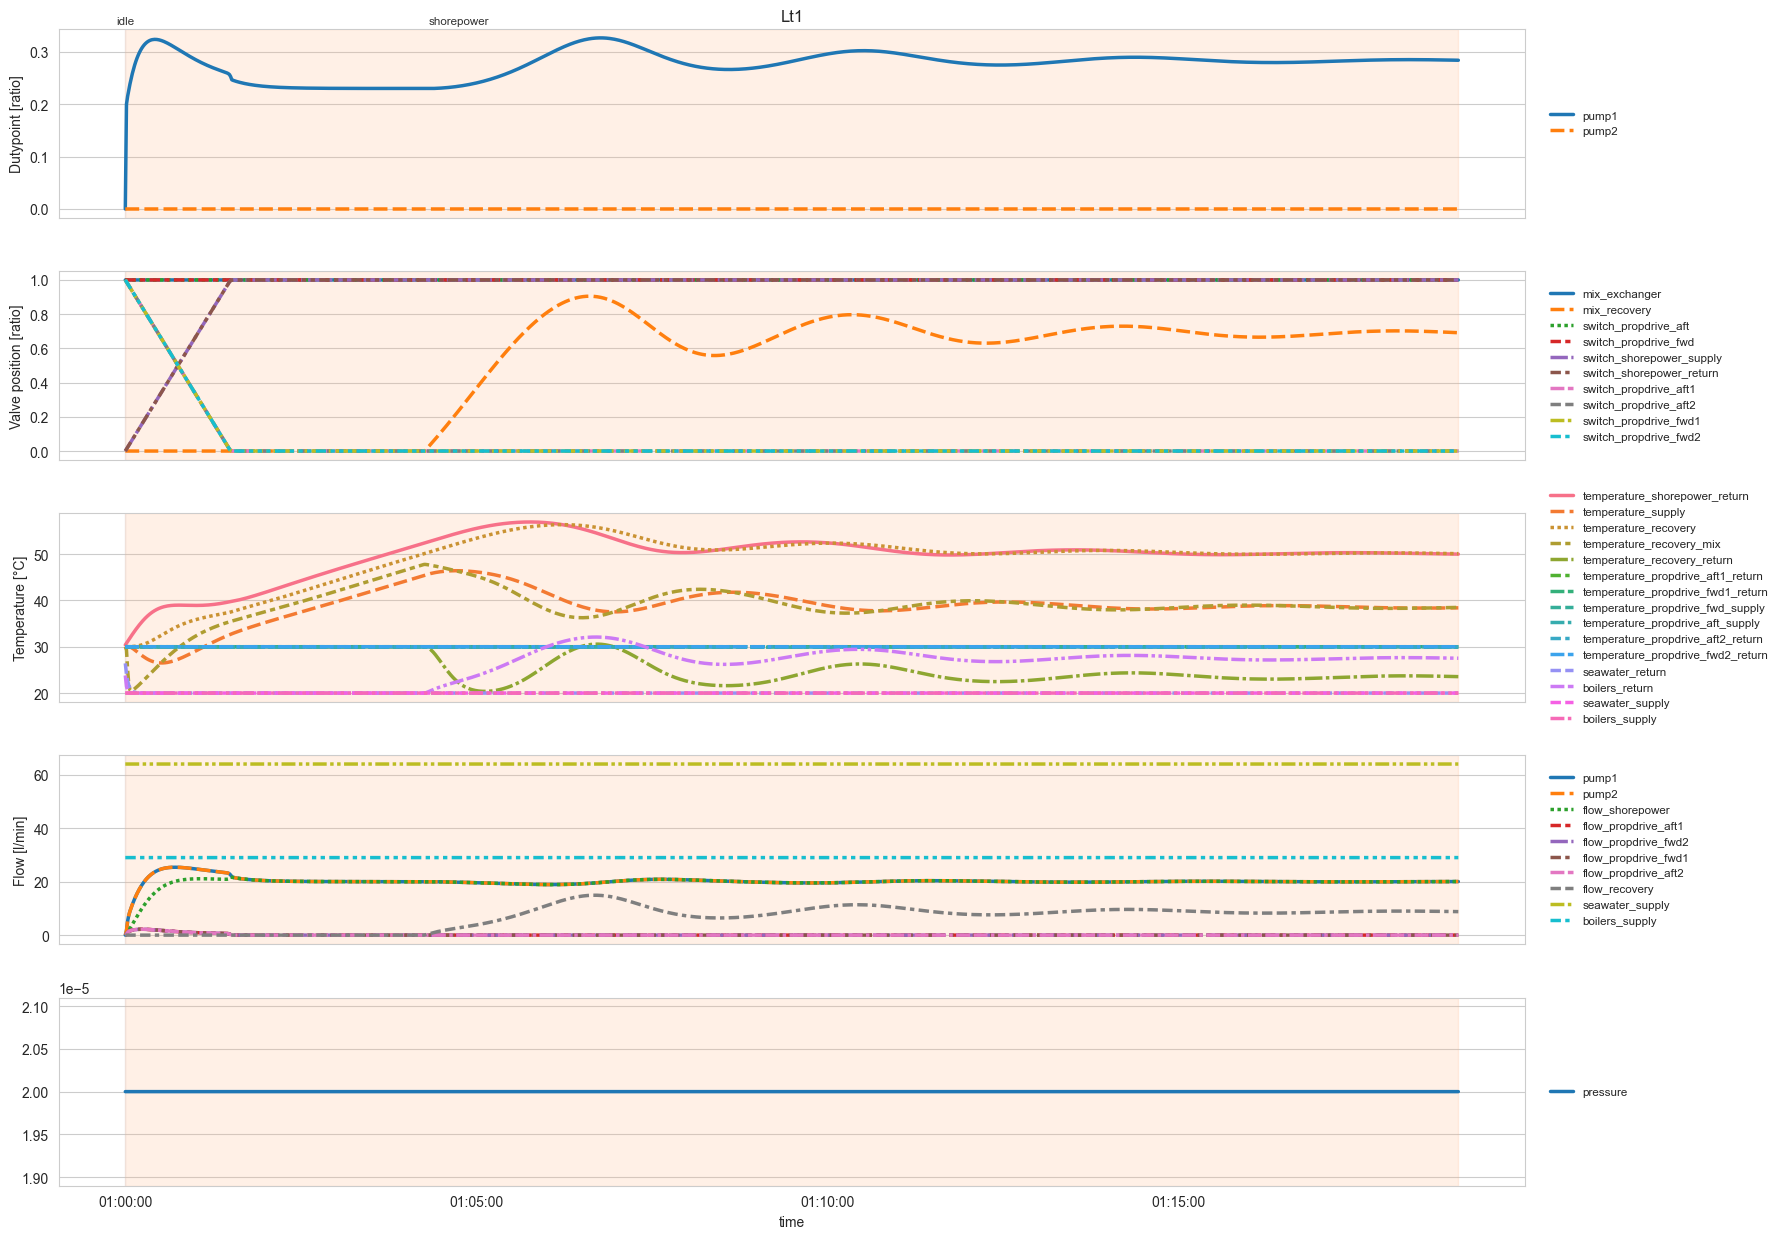

In [32]:
from analysis.analysis_utils import plot_result

plot_result(result, "plots/lt1.png");

In [ ]:
from thrs.simulation.io_mapping import flatten_model_values


result.select(
    [
        "time",
        *flatten_model_values(Lt1ControlValues.zero(), fmu_only=False).keys(),
        *flatten_model_values(Lt1SimulationInputs.zero(), fmu_only=False).keys(),
    ]
).write_csv("csv/lt1_run_inputs.csv")


result.select(
    [
        "time",
        *flatten_model_values(Lt1SensorValues.zero(), fmu_only=False).keys(),
        *flatten_model_values(Lt1SimulationOutputs.zero(), fmu_only=False).keys(),
    ]
).write_csv("csv/lt1_run_outputs.csv")